# Project Objective:
In this project, we will attempt to predict stock or cryptocurrency prices using machine learning techniques. We will evaluate the performance of our model and analyze whether it could potentially generate profits.

## Import Libraries

First, we import the necessary libraries. We'll use yfinance (Yahoo Finance) to retrieve stock and cryptocurrency data. The other libraries are commonly used for data processing, visualization, and building machine learning models.

In [5]:
!pip install yfinance pandas numpy matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


[notice] A new release of pip is available: 24.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


We first choose to perform our analysis on Bitcoin, which is a well-known cryptocurrency in the market. We set a start and end date to extract historical data.

Since we want to collect as much data as possible, and Bitcoin was initially released in 2009, we set the start date to 100 years ago. The yfinance library automatically adjusts the request to the earliest available date if the specified start date is too early.

In [6]:
crypto = 'BTC-CAD'  # Bitcoin price in Canadian dollars

end = datetime.now()  # Set the end date to today
start = datetime(end.year - 100, end.month, end.day)  # Set the start date 100 years ago to retrieve the maximum available data

crypto_data = yf.download(crypto, start=start, end=end)  # Download historical price data using yfinance

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BTC-CAD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


We successfully downloaded the data. Now, we'll explore it a bit to understand its structure and contents.

In [7]:
crypto_data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD
Date,,,,,,


In [8]:
crypto_data.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD
Date,,,,,,


We do have the latest data.

In [9]:
crypto_data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD,BTC-CAD
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
crypto_data.index
crypto_data.dtypes
crypto_data.shape[0]

0

We know that the closing price is an important factor in determining whether a cryptocurrency is trending upwards or downwards. Therefore, among the available features—high, low, open, and volume—we will focus our analysis on the closing price.

In [11]:
close_price = crypto_data[["Close"]] 
close_price 

Price,Close
Ticker,BTC-CAD
Date,


Let's start by plotting Bitcoin's closing price over time to get a sense of its historical trends.

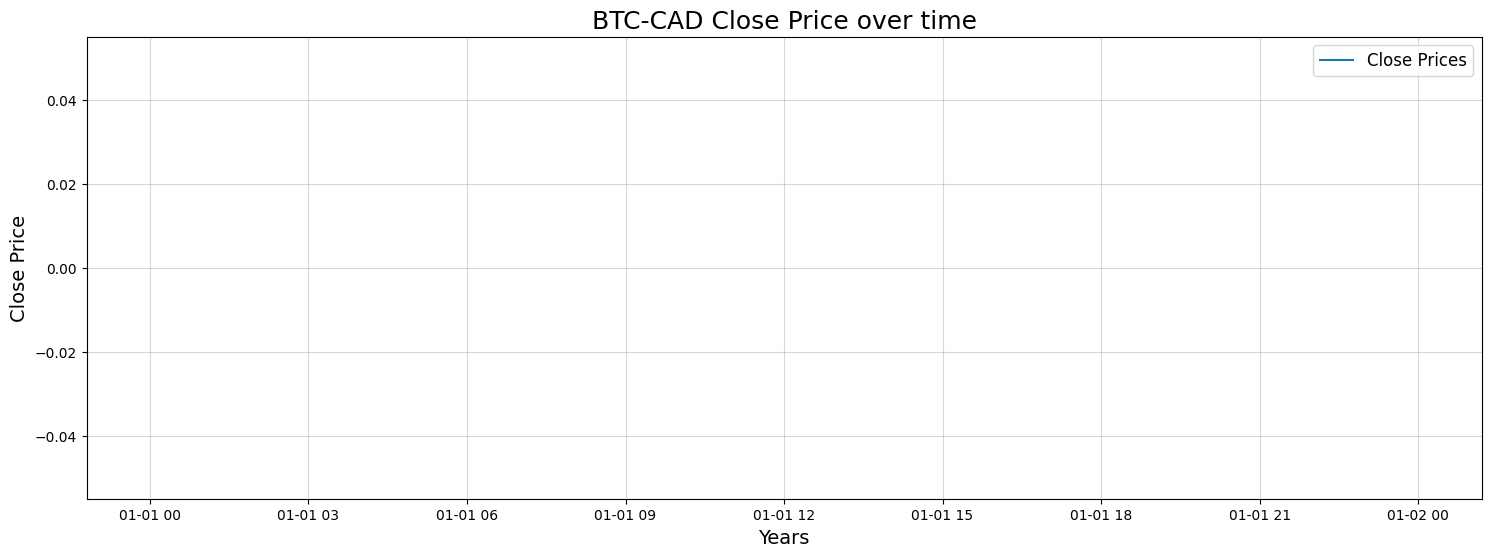

/usr/local/bin/python3


In [16]:
plt.figure(figsize = (18, 6))
plt.plot(close_price.index, close_price['Close'], label = 'Close Prices')
plt.title(crypto + " Close Price over time", fontsize = 18)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.5)
plt.legend(fontsize=12)
plt.show()


import sys
print(sys.executable)



To improve the performance of our analysis and speed up model training, we will normalize or scale our data. Scaling ensures that all values are within a similar range, which helps neural networks like LSTM converge more efficiently and avoid issues caused by large differences in feature magnitudes.

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_price[['Close']].dropna())

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by MinMaxScaler.

We are importing essential libraries for our model. Sequential allows us to stack layers linearly. Dense is a fully connected layer, while LSTM is used for handling sequential data, like time series. Finally, EarlyStopping helps to halt training early if the validation loss stops improving, preventing overfitting.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from keras.callbacks import EarlyStopping

To convert our time series data into supervised learning samples, we create sequences of past data (inputs) and the next day's price (output). We use the last 3% of the data (base_days) as input features and the next day's price as the target. The choice of 3% is a good choice after a series of testing. This process generates x_data (sequences of past prices) and y_data (next day's price) for model training.

In [4]:
x_data = []
y_data = []
base_days = int(crypto_data.shape[0]*0.03)

for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])  
    y_data.append(scaled_data[i])              

x_data = np.array(x_data)
y_data = np.array(y_data)

NameError: name 'crypto_data' is not defined

## Defining Training, Validation, and Testing Sets

Then, let's split the data into training, validation, and test sets. We use 90% of the data for training. Note that we have a small validation set because cryptocurrency and stock prices fluctuate significantly, we want to allow for some "overfitting" to better capture the volatility in the market.

In [ ]:
train_size = int(len(x_data) * 0.9)

x_train, y_train = x_data[:train_size], y_data[:train_size]

x_temp = x_data[train_size:]
y_temp = y_data[train_size:]

val_size = int(len(x_temp) * 0.25)

x_val = x_temp[:val_size]
y_val = y_temp[:val_size]

x_test = x_temp[val_size:]
y_test = y_temp[val_size:]

## Defining Deep Learning model
The first LSTM layer learns patterns from past data, while the second LSTM layer reduces the sequence to a single output. A Dense layer is added to capture complex features, and the final Dense layer predicts the next day's price. The model is compiled with the Adam optimizer and Mean Squared Error loss.

In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

## Model training
We use EarlyStopping to stop training if the val_loss doesn’t improve for 8 epochs, and restore the best weights. 

The reason for choosing the batch size to be 0.56% of the dataset size is based on a series of testings. While such a small batch size may increase training time, it helps better capture market volatility.

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size= int(crypto_data.shape[0]*0.0056),       
    epochs=20,           
    verbose=1,           
    shuffle=False        
    ,callbacks=[early_stop]
)


Next, we plot the training and validation loss to evaluate how well our model is learning and generalizing over time.

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Our LSTM model for predicting Bitcoin prices (BTC-CAD) performed well overall, with both training and validation losses showing a general downward trend throughout the 20 training epochs. Initially, the validation loss spiked as training loss dropped, suggesting early signs of overfitting. However, this gap closed over time, with validation loss eventually aligning closely with training loss, indicating improved generalization. The final validation loss reached a low of 3.9e-4, and training loss stabilized around 5e-4. It's worth noting that the low validation loss may be partly influenced by the small validation set size, which can sometimes lead to optimistic or less stable performance estimates. Overall, the model effectively captured useful patterns, making it practical for real-world trading strategies.

Now we begin making predictions for the testing period to evaluate how well our model performs on unseen data.

In [ ]:
predictions = model.predict(x_test)

inv_predictions = scaler.inverse_transform(predictions) # convert the data back
inv_y_test = scaler.inverse_transform(y_test)

Next, we plot the predicted prices alongside the actual prices to visually compare the model's performance and assess how accurately it predicts.

In [ ]:
plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(), 
        'Prediction': inv_predictions.flatten(),
    }, index = close_price.index[ train_size + val_size + base_days : ]
    )

plt.figure(figsize = (18, 6))

plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original')
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction')

plt.title("Prediction vs Actual Close Price", fontsize = 18)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.5)
plt.legend(fontsize=12)
plt.show()

The model preforms pretty well by showing strong trend alignment with actual close prices, capturing of underlying market patterns.

Note that there is a significant increase at the end of 2024, which is commonly attributed to Donald Trump winning the U.S. election. This is unusual, as the model should not have access to such information. However, this spike may be due to a combination of Bitcoin's natural bull market tendencies and the pattern observed during the U.S. election four years ago at the end of 2020, when a similar increase occurred. Additionally, we can see that our prediction is lower than the actual increase, which makes the outcome explainable.

## Trade bots
Next, we further evaluate the quality of our predictions by simulating buy and sell actions based on predicted prices using an automated trading bot.

We define a simple trading bot to simulate the profit or loss based on our model’s predictions. The initial_investment represents the starting amount, assumed to be fully used to buy the asset at the beginning of the test period. The bot uses proportion_to_sell to determine how much of the current holdings to sell when a price drop is predicted, and amount_to_buy to specify how many units to purchase when a price increase is expected. The inv_predictions and inv_y_test arrays contain the inverse-scaled predicted and actual prices, respectively. To prevent unlimited reinvestment, we introduce max_to_put_in, which sets a cap on the total amount of money that can be put back into the market. The bot simulates daily trades and returns the total profit made at the end.

This function is a oversimplified simulation of real market trading. The rule it follows is straightforward: for each day, it calculates the average predicted price over the next 2% of the total time period. If this average is higher than today’s predicted price and we haven’t yet reached our investment limit, the bot will buy. If the average is lower, it will sell. While this doesn’t capture the full complexity of actual trading, it provides a basic way to evaluate the usefulness of our predictions.

In [ ]:
def trade_bot(
    initial_investment: float,
    proportion_to_sell: float,
    amount_to_buy: float,
    inv_predictions: np.ndarray,
    inv_y_test: np.ndarray,
    max_to_put_in: float
) -> float:
    
    predictions = inv_predictions.flatten()
    actuals = inv_y_test.flatten()
    
    starting_price = predictions[0]
    units = initial_investment / starting_price
    cash = 0.0  

    saving = max_to_put_in

    days_predicting = int(len(predictions)*0.02)
    for i in range(len(predictions) - days_predicting): 
        predicted_today = predictions[i]
        avg_future_prediction = np.mean(predictions[i+1:i+days_predicting])
        actual_today = actuals[i]

        if avg_future_prediction > predicted_today:
            # BUY
            if actual_today * amount_to_buy < saving:
                saving -= actual_today * amount_to_buy
                units += amount_to_buy
            elif actual_today * amount_to_buy < cash:
                cash -= actual_today * amount_to_buy
                units += amount_to_buy
        elif units > 0 and avg_future_prediction < predicted_today:
            # SELL
            to_sell = min(units, proportion_to_sell)
            cash += actual_today * to_sell
            units -= to_sell

    # Final portfolio value (cash + value of remaining units)
    final_price = actuals[-1]
    total_value = cash + units * final_price + saving

    profit = total_value - initial_investment - max_to_put_in
    return float(profit)

In [ ]:
trade_bot(initial_investment=2000, proportion_to_sell= 0.25, amount_to_buy= 0.25, inv_predictions=inv_predictions, inv_y_test=inv_y_test, max_to_put_in= 100000)

We seem to be doing fairly well here by making a profit, starting with an initial investment of $2000 and a maximum investment limit of $10000.

We then define a slightly more sophisticated trading bot. This version takes into account a user-defined number of days to average future predicted prices and adjusts its buying/selling behavior based on how strong the predicted trend is. If the average predicted price is slightly higher than today's price, it buys a small amount; if it's moderately higher, it buys more; and if it's much higher, it buys aggressively. The same logic is applied to selling if the predicted average is lower. This allows for more nuanced decision-making based on trend strength.

In [ ]:
def trade_bot2(
    initial_investment: float,
    inv_predictions: np.ndarray,
    inv_y_test: np.ndarray,
    max_to_put_in: float,
    avg_days: int,
    buy_low: float,
    buy_mid: float,
    buy_high: float,
    sell_low: float,
    sell_mid: float,
    sell_high: float
) -> float:
    
    predictions = inv_predictions.flatten()
    actuals = inv_y_test.flatten()
    
    starting_price = predictions[0]
    units = initial_investment / starting_price
    cash = 0.0 
    saving = max_to_put_in

    for i in range(len(predictions) - avg_days): 
        predicted_today = predictions[i]
        avg_future_prediction = np.mean(predictions[i+1:i+avg_days])
        actual_today = actuals[i]

        change = (avg_future_prediction - predicted_today) / predicted_today

        # BUY Logic
        if change > 0:
            if change <= 0.05:
                amount = buy_low
            elif change <= 0.10:
                amount = buy_mid
            else:
                amount = buy_high

            if actual_today * amount < saving:
                saving -= actual_today * amount
                units += amount
            elif actual_today * amount < cash:
                cash -= actual_today * amount
                units += amount

        # SELL Logic
        elif change < 0 and units > 0:
            if abs(change) <= 0.02:
                to_sell = min(units, sell_low)
            elif abs(change) <= 0.05:
                to_sell = min(units, sell_mid)
            else:
                to_sell = min(units, sell_high)

            cash += actual_today * to_sell
            units -= to_sell

    final_price = actuals[-1]
    total_value = cash + units * final_price + saving

    profit = total_value - initial_investment - max_to_put_in
    return float(profit)

In [ ]:
trade_bot2(initial_investment=2000, inv_predictions=inv_predictions, inv_y_test=inv_y_test, max_to_put_in= 100000, avg_days= int(len(inv_predictions)*0.02), buy_low=0.25, buy_mid=0.35, buy_high=1, sell_low=0.25, sell_mid=0.35, sell_high=2)

As expected, the slightly more sophisticated trading bot works better, making us more money in the same period of time

## Unknown Future Prediction

We will now apply our model to predict prices for future days. However, since we do not have actual data for those days, we cannot assess the accuracy of the predictions. Nonetheless, we can still visualize the forecasted trend by plotting the predictions on a graph.


In [ ]:
days_to_predict = 10

last_base_days  = scaled_data[-base_days:].reshape(1, -1, 1)
future_predictions=[]
for _ in range(days_to_predict):
    next_days = model.predict(last_base_days)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_base_days = np.append(last_base_days[:, 1:, :], next_days.reshape(1, 1, -1), axis = 1)

In [ ]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15, 6))
plt.plot(range(1, len(future_predictions)+1), future_predictions, marker="o" ,label = 'Prediction Future Prices')

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for " + str(days_to_predict) + " Days", fontsize = 18)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()



# Tesla
We can also repeat the above process using a different stock or cryptocurrency. Our results from the previous predictions on Bitcoin might not be persuasive, as it is a bull market where any kind of investment in Bitcoin has the potential of making money. Next, we will be looking at stocks like Tesla, which had a bear market in recent days

In [ ]:
crypto = 'TSLA'  # Bitcoin price in Canadian dollars

end = datetime.now()  # Set the end date to today
start = datetime(end.year - 100, end.month, end.day)  # Set the start date 100 years ago to retrieve the maximum available data

crypto_data = yf.download(crypto, start=start, end=end)  # Download historical price data using yfinance

close_price = crypto_data[["Close"]]  # Extract only the 'Close' column from the dataset for analysis
close_price 

In [ ]:
plt.figure(figsize = (18, 6))
plt.plot(close_price.index, close_price['Close'], label = 'Close Prices')
plt.title(crypto + " Close Price over time", fontsize = 18)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.5)
plt.legend(fontsize=12)
plt.show()



In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_price[['Close']].dropna())

x_data = []
y_data = []
base_days = int(crypto_data.shape[0]*0.03)

for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])  
    y_data.append(scaled_data[i])             

x_data = np.array(x_data)
y_data = np.array(y_data)

train_size = int(len(x_data) * 0.9)

x_train, y_train = x_data[:train_size], y_data[:train_size]

x_temp = x_data[train_size:]
y_temp = y_data[train_size:]

val_size = int(len(x_temp) * 0.25)

x_val = x_temp[:val_size]
y_val = y_temp[:val_size]

x_test = x_temp[val_size:]
y_test = y_temp[val_size:]

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size= int(crypto_data.shape[0]*0.0056),       
    epochs=20,           
    verbose=1,           
    shuffle=False        
    ,callbacks=[early_stop]
)

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
predictions = model.predict(x_test)

inv_predictions = scaler.inverse_transform(predictions) # convert the data back
inv_y_test = scaler.inverse_transform(y_test)

plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(), 
        'Prediction': inv_predictions.flatten(),
    }, index = close_price.index[ train_size + val_size + base_days : ]
    )

plt.figure(figsize = (18, 6))

plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original')
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction')

plt.title("Prediction vs Actual Close Price", fontsize = 18)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.5)
plt.legend(fontsize=12)
plt.show()


In [ ]:
trade_bot(initial_investment=2000, proportion_to_sell= 50, amount_to_buy= 50, inv_predictions=inv_predictions, inv_y_test=inv_y_test, max_to_put_in= 100000)

In [ ]:
trade_bot2(initial_investment=2000, inv_predictions=inv_predictions, inv_y_test=inv_y_test, max_to_put_in= 100000, avg_days= int(len(inv_predictions)*0.02), buy_low=40, buy_mid=50, buy_high=100, sell_low=50, sell_mid=75, sell_high=150)

Our LSTM model for predicting Tesla stock prices performs surprisingly well, achieving very low training and validation loss while producing visually accurate predictions on the test set. This high accuracy suggests the model has effectively captured the underlying temporal patterns in Tesla’s price movements. Although there are signs of overfitting—such as early spikes and later fluctuations in validation loss—these may be justifiable given the relatively smooth, autocorrelated nature of short-term stock trends, where even recent price memory can offer strong predictive power. However, the problem should be solved by early stopping. Overall, training loss consistently decreased after the fluctuation between epoch 3 and 7, and validation loss mostly stabilized after early volatility. Furthermore, the model's practical viability is supported by our trading strategy: with an initial $2,000 investment and a maximum investment limit of $10000, the trade algorithms significantly grew the profit in a short period of time.

# Project Summary

In this project, we developed and evaluated an LSTM-based deep learning model to predict the price of crypto and stock. Using past price data, we preprocessed the data with normalization and constructed sequences for training, validation, and testing. The model consisted of stacked LSTM layers followed by dense layers, optimized with mean squared error loss and the Adam optimizer.

We visualized the performance of the model through prediction vs. actual price plots and observed that it captured the overall trend of the closing prices quite well. To further evaluate the practical utility of our predictions, we implemented two trading bots: a simple version and a more dynamic one. These bots simulated buying and selling behavior based on predicted future price trends and generated profits under certain conditions, demonstrating potential real-world applicability.

Additionally, we extended the analysis to a second dataset — Tesla stock prices — and found that the model generalized reasonably well, maintaining low loss and visually accurate predictions. While there were some signs of overfitting, the performance was justified given the smoothness and autocorrelation typical of short-term stock price data.

Overall, this project demonstrates how deep learning models can be used not only for time series forecasting but also for simulating investment strategies, combining financial insight with machine learning.

# references
https://www.youtube.com/watch?v=p-QY7JNGD60

https://www.youtube.com/watch?v=1O_BenficgE

https://www.geeksforgeeks.org/bitcoin-price-prediction-using-machine-learning-in-python/